In [19]:
# =====================================
# Import, load, clean, and filter data
# =====================================

import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Load dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Clean date and skills columns
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

df["job_skills"] = df["job_skills"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Keep only U.S. Data Engineer jobs
df_DE_US = df[
    (df["job_country"] == "United States") &
    (df["job_title_short"] == "Data Engineer")
].copy()

# Remove jobs without yearly salary data
df_DE_US = df_DE_US.dropna(subset=["salary_year_avg"])

df_DE_US.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."
307,Data Engineer,Data Engineer,"Austin, TX",via LinkedIn,Full-time,False,"New York, United States",2023-10-03 13:05:31,False,False,United States,year,185000.0,NaN,hackajob,"[nosql, sql]","{'programming': ['nosql', 'sql']}"
339,Data Engineer,Global Market Leading Energy Firm - Staff Data...,United States,via LinkedIn,Full-time,False,"California, United States",2023-09-22 13:07:57,False,False,United States,year,195000.0,NaN,Xcede,NaN,NaN
380,Data Engineer,Snaplogic Data Engineer,"Durham, NC",via LinkedIn,Full-time,False,"Illinois, United States",2023-08-16 13:26:21,True,False,United States,year,97500.0,NaN,KTek Resourcing,"[sql, python]","{'programming': ['sql', 'python']}"


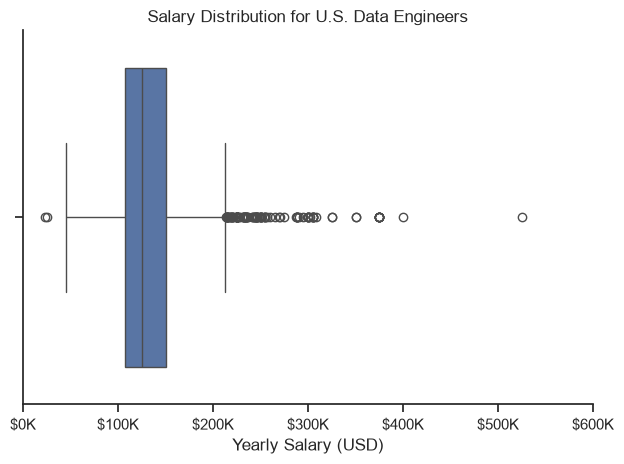

In [20]:
# =====================================
# Data Engineer salary distribution
# =====================================

# Clean Seaborn styling
sns.set_theme(style="ticks")

# Boxplot shows median, quartiles, spread, and salary outliers
sns.boxplot(
    data=df_DE_US,
    x="salary_year_avg"
)

# Chart labels
plt.title("Salary Distribution for U.S. Data Engineers")
plt.xlabel("Yearly Salary (USD)")
plt.ylabel("")

# Limit chart to $0–$600K so extreme values don't stretch the plot
plt.xlim(0, 600000)

# Format 100000 -> $100K
salary_format = plt.FuncFormatter(
    lambda x, pos: f"${int(x / 1000)}K"
)

plt.gca().xaxis.set_major_formatter(salary_format)

# Remove unnecessary chart borders
sns.despine()

plt.tight_layout()
plt.show()

In [21]:
# =====================================
# Compare salaries across major U.S.
# data careers
# =====================================

# Job titles to compare
# Job titles ordered from highest to lowest seniority
job_titles = [
    "Senior Data Scientist",
    "Senior Data Engineer",
    "Data Scientist",
    "Data Engineer",
    "Senior Data Analyst",
    "Data Analyst"
]

# Filter U.S. jobs for the selected roles
df_salary = df[
    (df["job_country"] == "United States") &
    (df["job_title_short"].isin(job_titles))
].copy()

# Remove rows without yearly salary information
df_salary = df_salary.dropna(subset=["salary_year_avg"])

df_salary.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."


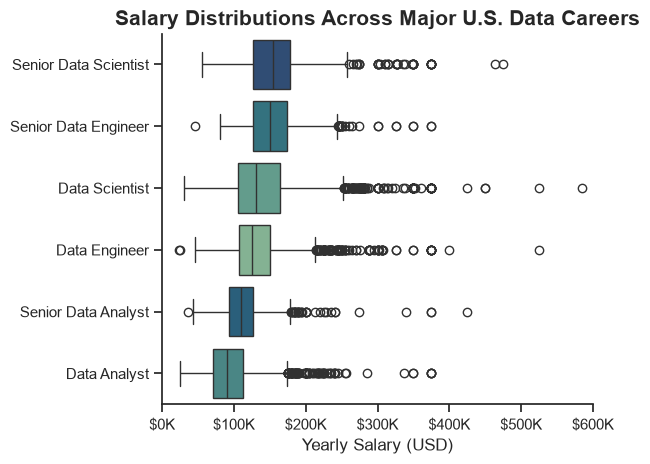

In [22]:
# =====================================
# Compare salary distributions
# =====================================

import matplotlib.ticker as mtick

# Clean Seaborn styling
sns.set_theme(style="ticks")

# Draw salary distribution boxplots
sns.boxplot(
    data=df_salary,
    x="salary_year_avg",
    y="job_title_short",
    order=job_titles,           # Display in our chosen order
    palette="crest",
    hue="job_title_short",
    legend=False
)

# Remove unnecessary chart borders
sns.despine()

# Chart title and labels
plt.title(
    "Salary Distributions Across Major U.S. Data Careers",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Yearly Salary (USD)")
plt.ylabel("")

# Limit x-axis for readability
plt.xlim(0, 600000)

# Display salaries as $100K instead of 100000
plt.gca().xaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, pos: f"${int(x/1000)}K")
)

plt.tight_layout()
plt.show()

# Investigate Median Salary vs. Skill for U.S. Data Engineers

## Objective

Analyze which technical skills are associated with the highest median salaries for Data Engineers and compare them with the skills most frequently requested by employers.

## Methodology

1. Filter U.S. Data Engineer job postings
2. Remove postings without yearly salary data
3. Explode the skills column so each skill becomes its own row
4. Calculate skill frequency and median salary
5. Identify the highest-paying skills
6. Identify the most in-demand skills
7. Compare both groups using Seaborn visualizations

In [23]:
# ============================================
# Prepare Data Engineer salary + skill data
# ============================================

# Keep only U.S. Data Engineer jobs
df_DE_US = df[
    (df["job_title_short"] == "Data Engineer") &
    (df["job_country"] == "United States")
].copy()

# Remove jobs where yearly salary is missing
df_DE_US = df_DE_US.dropna(subset=["salary_year_avg"])

# Split the job_skills list so every skill gets its own row
# Example: ['python', 'sql', 'aws'] -> three rows
df_DE_US = df_DE_US.explode("job_skills")

# Preview only the columns we care about
df_DE_US[
    ["salary_year_avg", "job_skills"]
].head()

,salary_year_avg,job_skills
92,120000.0,sql
92,120000.0,python
146,129500.0,golang
146,129500.0,scala
146,129500.0,python


In [24]:
# ============================================
# Calculate salary and demand by skill
# ============================================

# Group jobs by skill and calculate:
# count  -> how many job postings mention the skill
# median -> median yearly salary for jobs requiring the skill
df_DE_skills = (
    df_DE_US
    .groupby("job_skills")["salary_year_avg"]
    .agg(["count", "median"])
)

df_DE_skills.head()

,count,median
job_skills,,
airflow,458,140000.0
airtable,2,122500.0
alteryx,57,115000.0
angular,27,140000.0
angular.js,1,116600.0


In [25]:
# ============================================
# Create the two skill groups we want to compare
# ============================================

# Top 10 skills ranked by median salary
df_DE_top_pay = (
    df_DE_skills
    .sort_values(
        by="median",
        ascending=False          # Highest salary first
    )
    .head(10)
)

# Top 10 skills ranked by number of job postings
# Then sort those 10 by median salary for easier plotting
df_DE_top_demand = (
    df_DE_skills
    .sort_values(
        by="count",
        ascending=False          # Most requested first
    )
    .head(10)
    .sort_values(
        by="median",
        ascending=False
    )
)

df_DE_top_pay

,count,median
job_skills,,
mongo,78,208114.0
vue,1,200000.0
solidity,1,192500.0
node,24,190000.0
ggplot2,2,176250.0
macos,2,172000.0
clojure,2,170866.5
atlassian,18,169860.0
rust,7,165000.0


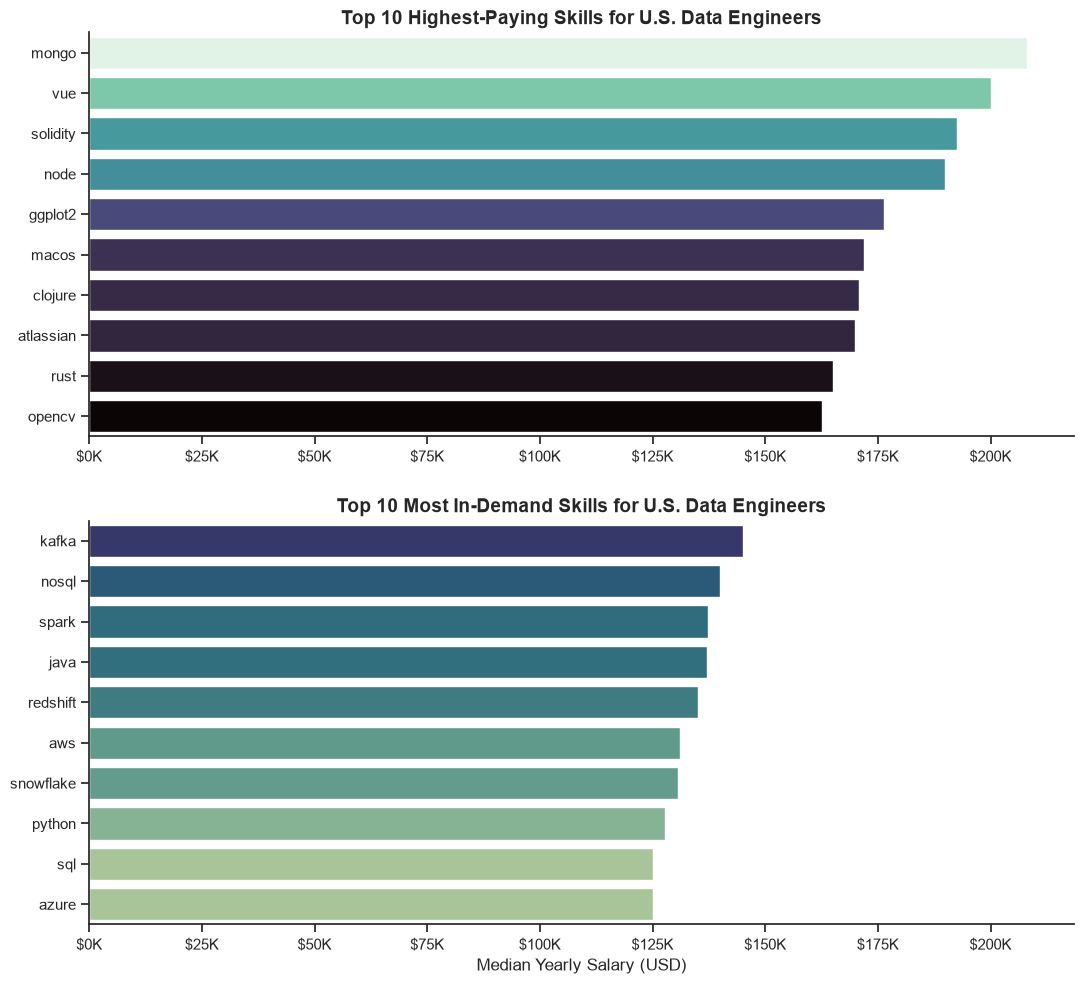

In [26]:
# ============================================
# Compare highest-paying vs. most-demanded
# Data Engineer skills
# ============================================

# Use a clean Seaborn theme
sns.set_theme(style="ticks")

# Create two vertically stacked charts
fig, ax = plt.subplots(
    2,
    1,
    figsize=(11, 10)
)

# ------------------------------------------------
# Chart 1: Top 10 highest-paying skills
# ------------------------------------------------

sns.barplot(
    data=df_DE_top_pay.reset_index(),
    x="median",                     # Bar length = median salary
    y="job_skills",                 # One bar for each skill
    hue="median",                   # Color intensity represents salary
    palette="mako",                 # Seaborn gradient palette
    legend=False,
    ax=ax[0]
)

ax[0].set_title(
    "Top 10 Highest-Paying Skills for U.S. Data Engineers",
    fontsize=14,
    weight="bold"
)

ax[0].set_ylabel("")
ax[0].set_xlabel("")

# Format salary values:
# 150000 -> $150K
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${int(x / 1000)}K"
    )
)

# ------------------------------------------------
# Chart 2: Top 10 most in-demand skills
# ------------------------------------------------

sns.barplot(
    data=df_DE_top_demand.reset_index(),
    x="median",                     # Compare median salary
    y="job_skills",                 # Skill names
    hue="median",                   # Color also represents salary
    palette="crest",
    legend=False,
    ax=ax[1]
)

ax[1].set_title(
    "Top 10 Most In-Demand Skills for U.S. Data Engineers",
    fontsize=14,
    weight="bold"
)

ax[1].set_ylabel("")
ax[1].set_xlabel("Median Yearly Salary (USD)")

# Use the SAME x-axis range as the first chart
# so salary differences are visually comparable
ax[1].set_xlim(
    ax[0].get_xlim()
)

# Format salary axis
ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${int(x / 1000)}K"
    )
)

# Remove unnecessary top/right borders
sns.despine()

# Add space between charts and prevent overlap
fig.tight_layout(h_pad=2)

plt.show()